# Fashion Product Adoption Experiments

## The purpose of this notebook
USE the simulation to answer our research question

create_network()
       ↓
select_influencer()
       ↓
initialise_customers()
       ↓
┌─────────────────────────┐
│ purchase_probability()  │
│          ↓              │
│ simulation_step()       │ ← repeat over time
└─────────────────────────┘
       ↓
run_simulation()
       ↓
results

## 1. Research Question

How do influencer position and social influence strength affect the adoption of a new fashion product within a consumer social network?



## 2. Model Parameters

Explain the parameters used in the experiments.


### 2.1 Choosing Network Type
We use a Barabási–Albert network as a simplified consumer social network because its heterogeneous degree distribution produces highly connected nodes, allowing controlled comparison of influencer positions.

#### Comparison of Candidate Network Models
| Network | Basic idea | Fit for our project |
|---|---|---|
| Erdős–Rényi random | Connections form randomly with similar opportunity | ⚠️ Usable, but less natural for studying influential hubs |
| Watts–Strogatz small-world | Strong local connections + some long-distance links | ✅ Interesting for social communities |
| **Barabási–Albert** | Some nodes become highly connected hubs | **Selected: provides heterogeneous node degrees suitable for comparing influencer positions** |

## 3. Baseline Simulation

Run and visualise one simulation to check model behaviour.



### 3.1 Initialisation

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.model import create_network, select_influencer

### 3.2 Get the highest degree customer

In [3]:
G = create_network(100, 3)

print("Number of customers:", G.number_of_nodes())
print("Number of connections:", G.number_of_edges())

degrees = dict(G.degree())

highest_degree_customer = max(
    degrees,
    key=degrees.get
)

print("Highest degree customer:", highest_degree_customer)
print("Degree:", G.degree(highest_degree_customer))

Number of customers: 100
Number of connections: 291
Highest degree customer: 0
Degree: 33


In [4]:
# Test influencer

central_influencer = select_influencer(
    G,
    "central"
)

less_central_influencer = select_influencer(
    G,
    "less_central"
)

print(
    "Central influencer:",
    central_influencer,
    "Degree:",
    G.degree(central_influencer)
)

print(
    "Less-central influencer:",
    less_central_influencer,
    "Degree:",
    G.degree(less_central_influencer)
)

Central influencer: 0 Degree: 33
Less-central influencer: 86 Degree: 3


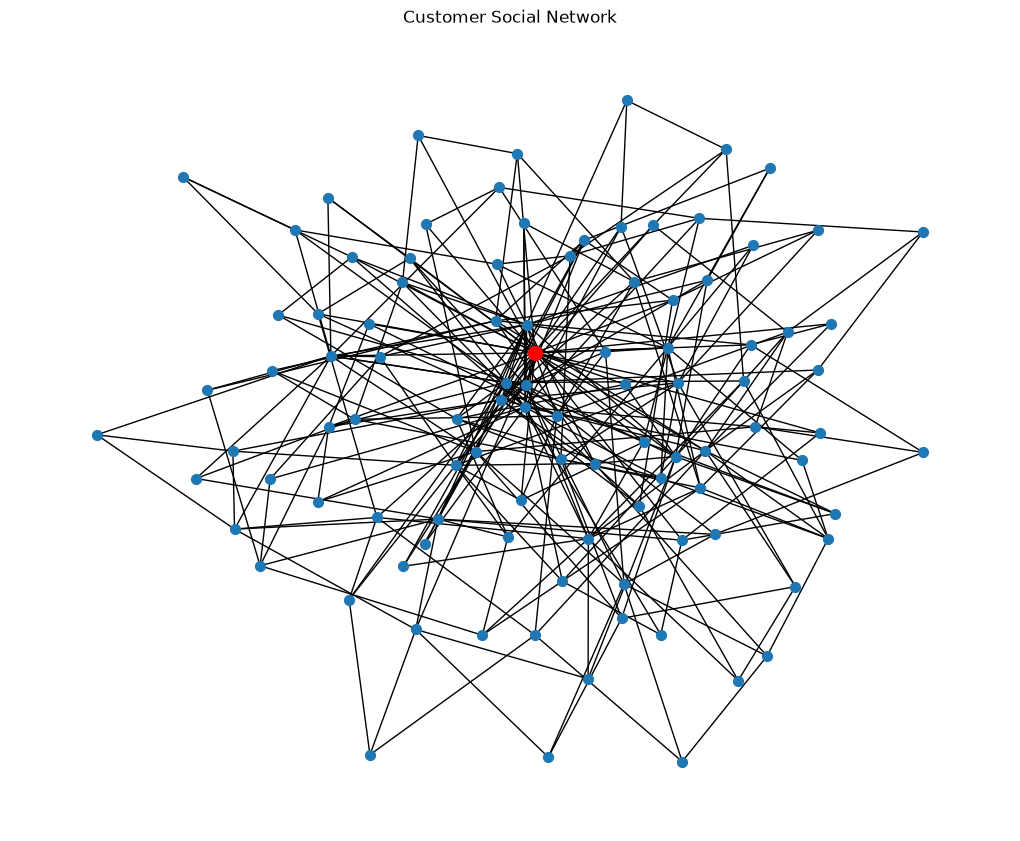

In [4]:
# Calculate positions once
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

# Draw the whole network
nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False
)

# Highlight highest-degree customer
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[highest_degree_customer],
    node_size=100,
    node_color="red"
)

plt.title("Customer Social Network")
plt.show()

## 4. Experiment 1 — Influencer Strategy

Compare highly central and less-central influencer placement while controlling other model parameters.



## 5. Experiment 2 — Social Influence Strength

Compare different levels of social influence.



## 6. Results

Analyse final adoption rate and adoption speed.



## 7. Discussion

Explain what the results mean and discuss limitations.